# Roketsan Araç Tespiti · EDA → YOLO Veri Hazırlığı → Eğitim (tek notebook, Kaggle)

Drone görüntülerinde alanı **≥ 200 px²** olan araçları tespit edip `car`, `van`, `truck`, `bus` olarak sınıflandıran bir model eğitiyoruz.
Metrik **mAP@0.5**: her sınıfın AP'si ayrı hesaplanır, skor 4 sınıfın **eşit ağırlıklı** ortalamasıdır.

| Bölüm | İçerik |
|---|---|
| 1. Kurulum | Paket kurulumu, veri klasörünün bulunması, veri sürümü kontrolü |
| 2. EDA | Dosya envanteri, sınıf dağılımı, görüntü boyutları (train ve test), kutu geometrisi, yoğunluk, görsel örnekler, resize etkisi |
| 3. Veri hazırlığı | Takımın `scene_holdout_v2` split'i, CSV'den YOLO formatına dönüşüm, doğrulama |
| 4. Eğitim | YOLO11m, `imgsz=1280`, 100 epoch + erken durdurma (`patience=20`), T4×2 (DDP) |
| 5. Değerlendirme | Yarışma metriğiyle (mAP@0.5) val skoru: düz ve test dağılımına göre **ağırlıklı**; sınıf ve stratum kırılımı, hata analizi |
| 6. Çıktılar | `best.pt`, val tahminleri, özet (`/kaggle/working/outputs`) |

### Kaggle'da çalıştırma
1. **Import:** *Code → New Notebook → File → Import Notebook* ile bu dosyayı yükle.
2. **Input:** *Add Input* ile repodaki `data/` klasörünün yüklendiği dataset'i ekle (`axilion/raw-roketsan-dataset`:
   `train/annotations.csv`, `train/images/`, `test/images/`, `sample_submission.csv`). Notebook bu dosyaları `/kaggle/input` altında kendisi bulur.
3. **Ayarlar:** *Accelerator → GPU T4 ×2*, *Internet → On* (Ultralytics kurulumu ve ön-eğitimli ağırlıklar için).
4. **Çalıştır:** *Save Version → Save & Run All (Commit)*. Eğitim arka planda sürer: T4×2'de epoch başına ~5.2 dk,
   100 epoch ~8.6 saat (erken durursa daha kısa); tüm notebook ~9–9.5 saat. Kaggle'ın 12 saatlik oturum sınırının altında.
5. **Sonuç:** Sürümün *Output* sekmesinde `outputs/<deney>/` klasörü.

GPU yoksa (ör. yerel bilgisayar) notebook otomatik olarak **smoke test** moduna geçer: küçük bir alt küme, 1 epoch, CPU.

## 0. Ayarlar

In [1]:
MODEL = "yolo11m.pt"   # yolo11n.pt / yolo11s.pt / yolo11m.pt ...
IMGSZ = 1280           # küçük nesneler için yüksek çözünürlük (bkz. EDA 2.7)
EPOCHS = 100
PATIENCE = 20          # val mAP50-95 20 epoch boyunca iyileşmezse eğitim erken durur
BATCH_PER_GPU = 4      # T4'te YOLO11m@1280 için 8 OOM veriyor, 4 çalışıyor. nbs=64 gradyan biriktirmesi etkin batch'i 64'te tutar
RUN_EDA = True         # yalnızca eğitim için False yapılabilir
SEED = 42
SPLIT_NAME = "scene_holdout_v2"  # takımın split'i (splits/scene_holdout_v2, furkan/src/make_scene_holdout_v2.py)
EXPECTED_SHA256 = "c946f29a627438bc4567544cc654234df2eab6a8e342a9ee4d9a6fd997e857ce"  # annotations.csv (takımın split'i bu sürümle oluşturuldu)

## 1. Kurulum

In [2]:
import os, subprocess, sys
from pathlib import Path

ON_KAGGLE = Path("/kaggle/input").exists()
if ON_KAGGLE:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics==8.4.163"], check=True)
os.environ.setdefault("PYTORCH_ALLOC_CONF", "expandable_segments:True")  # CUDA bellek parçalanmasını azaltır

import hashlib, json, random, shutil, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
import seaborn as sns
import torch
from PIL import Image, ImageDraw
import ultralytics
from ultralytics import YOLO

N_GPU = torch.cuda.device_count()
SMOKE = N_GPU == 0
WORK = Path("/kaggle/working") if ON_KAGGLE else Path.cwd() / "kaggle_local"
WORK.mkdir(parents=True, exist_ok=True)

CLASSES = ["car", "van", "truck", "bus"]
CLASS_COLORS = {"car": "#2a78d6", "van": "#eb6834", "truck": "#1baf7a", "bus": "#eda100"}
SPLIT_COLORS = {"train": "#52514e", "test": "#4a3aa7"}
MIN_AREA = 200
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12, "axes.edgecolor": "#c9c8c2",
                     "grid.color": "#ecebe7", "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", "{:,.2f}".format)


def find_file(root: Path, rel: str) -> Path | None:
    # rglob, Python < 3.13'te symlink'li klasörlere girmez; Kaggle input'ları symlink olabilir
    parts = Path(rel).parts
    for dirpath, dirnames, filenames in os.walk(root, followlinks=True):
        dirnames[:] = [d for d in dirnames if d != "images"]  # binlerce görüntüyü tarama
        if parts[-1] in filenames and (Path(dirpath) / parts[-1]).parts[-len(parts):] == parts:
            return Path(dirpath) / parts[-1]
    return None


search_roots = [Path("/kaggle/input")] if ON_KAGGLE else [p / "data" for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").exists()][:1]
ann_file = next((f for r in search_roots if (f := find_file(r, "train/annotations.csv"))), None)
assert ann_file is not None, f"train/annotations.csv bulunamadı. Aranan yerler: {search_roots}. Veri dataset'i input olarak eklendi mi?"
DATA = ann_file.parents[1]
TRAIN_IMG_DIR, TEST_IMG_DIR = DATA / "train" / "images", DATA / "test" / "images"
HAS_TEST = TEST_IMG_DIR.exists()

sha = hashlib.sha256(ann_file.read_bytes()).hexdigest()
pd.Series({
    "Ortam": "Kaggle" if ON_KAGGLE else "Yerel",
    "Mod": "SMOKE TEST" if SMOKE else "TAM EĞİTİM",
    "GPU": ", ".join(torch.cuda.get_device_name(i) for i in range(N_GPU)) or "yok",
    "ultralytics / torch": f"{ultralytics.__version__} / {torch.__version__}",
    "Veri klasörü": str(DATA),
    "Test görüntüleri var mı": HAS_TEST,
    "annotations.csv sürümü doğru mu": sha == EXPECTED_SHA256,
}, name="").to_frame()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 4.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


,
Ortam,Kaggle
Mod,TAM EĞİTİM
GPU,"Tesla T4, Tesla T4"
ultralytics / torch,8.4.163 / 2.10.0+cu128
Veri klasörü,/kaggle/input/datasets/axilion/raw-roketsan-da...
Test görüntüleri var mı,True
annotations.csv sürümü doğru mu,True


## 2. Keşifsel Veri Analizi (EDA)
Her alt bölümün sonunda **Ne öğrendik?** notu var; bölüm 2.8, bulguları modelleme kararlarına çeviriyor.

### 2.1 Dosya envanteri ve tutarlılık kontrolleri

In [3]:
raw = pd.read_csv(ann_file)
ann = raw.drop_duplicates().reset_index(drop=True)   # EDA: 1 birebir tekrar eden satır var
ann["area"] = ann["w"] * ann["h"]
train_ids = sorted(p.stem for p in TRAIN_IMG_DIR.glob("*.jpg"))
test_ids = sorted(p.stem for p in TEST_IMG_DIR.glob("*.jpg")) if HAS_TEST else []
annotated = set(ann["image_id"])

display(pd.Series({
    "Train görüntüsü": len(train_ids),
    "Test görüntüsü": len(test_ids),
    "Etiket satırı (ham / tekrarsız)": f"{len(raw):,} / {len(ann):,}",
    "Arka plan (etiketsiz) train görüntüsü": len(set(train_ids) - annotated),
}, name="adet").to_frame())
pd.Series({
    "Her etiketin görüntü dosyası var": annotated <= set(train_ids),
    "Train ve test id'leri ayrık": not (set(train_ids) & set(test_ids)),
    "Eksik değer yok": not raw.isna().any().any(),
    "w, h > 0": bool(((raw["w"] > 0) & (raw["h"] > 0)).all()),
    f"Tüm kutular ≥ {MIN_AREA} px²": bool((ann["area"] >= MIN_AREA).all()),
    "Etiketler beklenen 4 sınıf": set(ann["label"]) <= set(CLASSES),
}, name="geçti mi?").to_frame()

,adet
Train görüntüsü,6471
Test görüntüsü,2118
Etiket satırı (ham / tekrarsız),"165,349 / 165,348"
Arka plan (etiketsiz) train görüntüsü,290


,geçti mi?
Her etiketin görüntü dosyası var,True
Train ve test id'leri ayrık,True
Eksik değer yok,True
"w, h > 0",True
Tüm kutular ≥ 200 px²,True
Etiketler beklenen 4 sınıf,True


### 2.2 Sınıf dağılımı

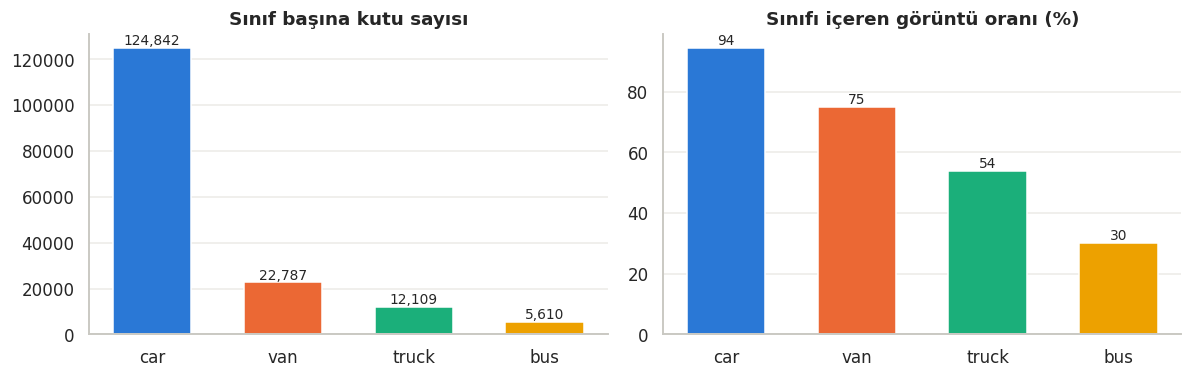

,kutu,kutu payı (%),görüntülerin (%),mAP ağırlığı (%)
label,,,,
car,124842,75.50,94.31,25.00
van,22787,13.78,74.95,25.00
truck,12109,7.32,53.99,25.00
bus,5610,3.39,30.20,25.00


In [4]:
box_counts = ann["label"].value_counts().reindex(CLASSES)
img_presence = ann.groupby("label")["image_id"].nunique().reindex(CLASSES)
class_table = pd.DataFrame({"kutu": box_counts, "kutu payı (%)": box_counts / box_counts.sum() * 100,
                            "görüntülerin (%)": img_presence / len(train_ids) * 100, "mAP ağırlığı (%)": 25.0})
if RUN_EDA:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    for ax, col, title in [(axes[0], "kutu", "Sınıf başına kutu sayısı"), (axes[1], "görüntülerin (%)", "Sınıfı içeren görüntü oranı (%)")]:
        ax.bar(CLASSES, class_table[col], color=[CLASS_COLORS[c] for c in CLASSES], width=0.6)
        for k, v in enumerate(class_table[col]):
            ax.text(k, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
        ax.set_title(title)
        ax.grid(axis="x", visible=False)
    plt.tight_layout()
    plt.show()
class_table

**Ne öğrendik?** Kutuların ~%75'i `car`, yalnızca ~%3'ü `bus`. Ama mAP'te **her sınıf %25 ağırlıkta**: az örnekli sınıflarda alınan her AP puanı car'daki kadar değerli.

### 2.3 Görüntü boyutları: train ve test

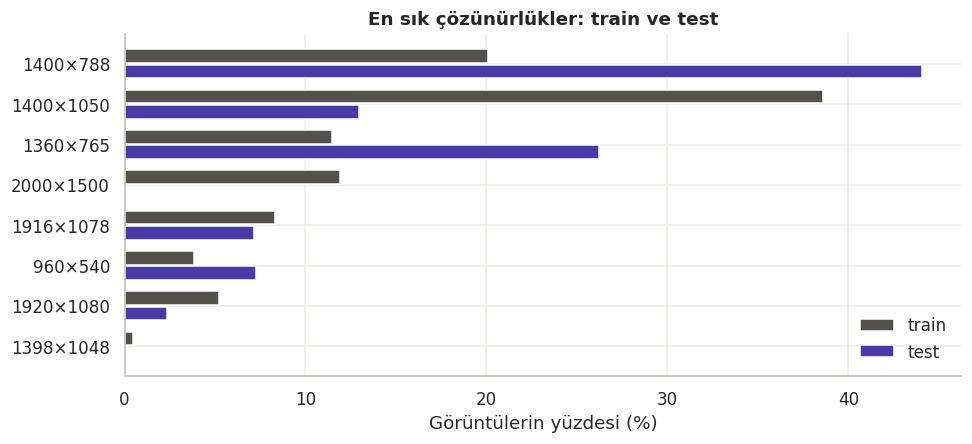

,train,test
1400×788,20.10,44.10
1400×1050,38.60,12.90
1360×765,11.50,26.30
2000×1500,11.90,0.00
1916×1078,8.30,7.10
960×540,3.90,7.30
1920×1080,5.20,2.40
1398×1048,0.50,0.00


In [5]:
def read_sizes(ids, folder):
    rows = []
    for i in ids:
        with Image.open(folder / f"{i}.jpg") as im:  # yalnızca header okunur
            rows.append((i, *im.size))
    return pd.DataFrame(rows, columns=["image_id", "width", "height"]).set_index("image_id")


sizes = read_sizes(train_ids, TRAIN_IMG_DIR)
test_sizes = read_sizes(test_ids, TEST_IMG_DIR) if HAS_TEST else sizes.iloc[:0]
res_of = lambda s: s["width"].astype(str) + "×" + s["height"].astype(str)
res_share = pd.DataFrame({"train": res_of(sizes).value_counts(normalize=True) * 100,
                          "test": res_of(test_sizes).value_counts(normalize=True) * 100}).fillna(0)
res_share = res_share.loc[res_share.max(axis=1).sort_values(ascending=False).index[:8]]
if RUN_EDA and HAS_TEST:
    fig, ax = plt.subplots(figsize=(9, 4.2))
    y = np.arange(len(res_share))
    for split, off in [("train", -0.19), ("test", 0.19)]:
        ax.barh(y + off, res_share[split], height=0.34, color=SPLIT_COLORS[split], label=split)
    ax.set_yticks(y, res_share.index)
    ax.invert_yaxis()
    ax.set_xlabel("Görüntülerin yüzdesi (%)")
    ax.set_title("En sık çözünürlükler: train ve test")
    ax.legend(frameon=False, loc="lower right")
    plt.tight_layout()
    plt.show()
res_share.round(1)

**Ne öğrendik?** Çözünürlükler heterojen ve **test dağılımı train'den farklı**: testte 1400×788 ve 1360×765 baskın, train'de 1400×1050.
Bu yüzden `scene_holdout_v2` split'inde val, testin çözünürlük × parlaklık dağılımına göre seçildi ve değerlendirmede
test dağılımına göre **ağırlıklı mAP** ile stratum bazında skorlar raporlanıyor (bölüm 3 ve 5).

### 2.4 Kutu geometrisi

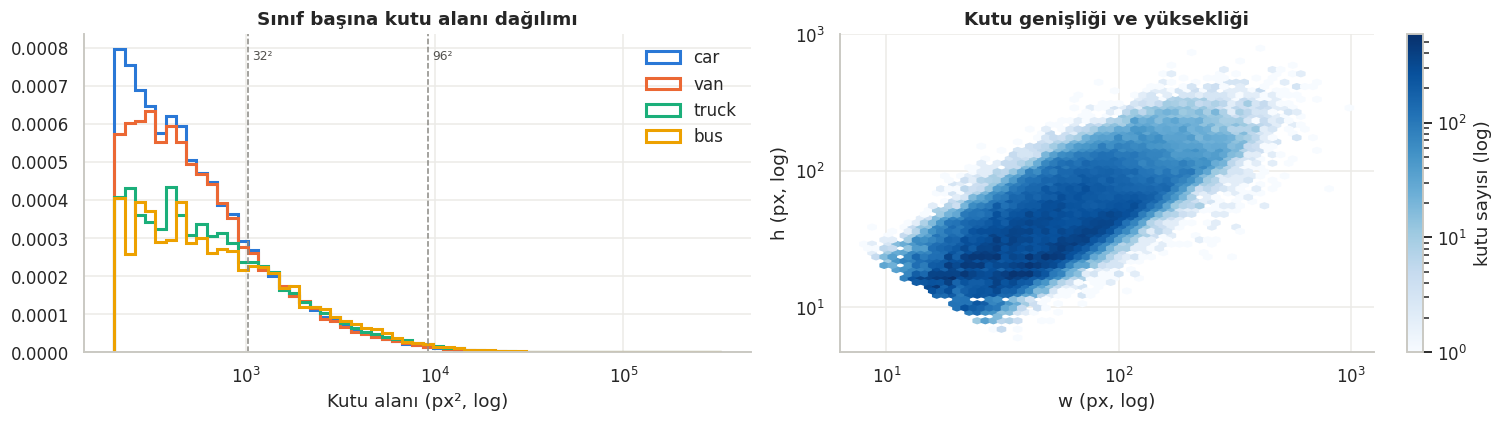

size_bin,200–512,512–1024 (≤32²),1024–4096,4096–9216 (≤96²),> 9216
label,,,,,
car,20.00,19.90,36.10,14.50,9.60
van,18.00,19.60,35.70,14.90,11.80
truck,11.70,14.90,37.40,18.20,17.90
bus,10.70,13.20,38.50,19.70,17.80


In [6]:
ann = ann.join(sizes, on="image_id")
size_bins = [MIN_AREA, 512, 32**2, 64**2, 96**2, np.inf]
size_labels = ["200–512", "512–1024 (≤32²)", "1024–4096", "4096–9216 (≤96²)", "> 9216"]
ann["size_bin"] = pd.cut(ann["area"], bins=size_bins, labels=size_labels, right=False)
if RUN_EDA:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    bins = np.logspace(np.log10(MIN_AREA), np.log10(ann["area"].max()), 60)
    for c in CLASSES:
        axes[0].hist(ann.loc[ann["label"] == c, "area"], bins=bins, density=True, histtype="step", linewidth=2,
                     color=CLASS_COLORS[c], label=c)
    for thr, name in [(32**2, "32²"), (96**2, "96²")]:
        axes[0].axvline(thr, color="#8a8984", linestyle="--", linewidth=1)
        axes[0].text(thr * 1.05, axes[0].get_ylim()[1] * 0.92, name, fontsize=8, color="#52514e")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("Kutu alanı (px², log)")
    axes[0].set_title("Sınıf başına kutu alanı dağılımı")
    axes[0].legend(frameon=False)
    hb = axes[1].hexbin(ann["w"], ann["h"], gridsize=60, bins="log", cmap="Blues", xscale="log", yscale="log", mincnt=1)
    axes[1].set_xlabel("w (px, log)")
    axes[1].set_ylabel("h (px, log)")
    axes[1].set_title("Kutu genişliği ve yüksekliği")
    fig.colorbar(hb, ax=axes[1], label="kutu sayısı (log)")
    plt.tight_layout()
    plt.show()
(pd.crosstab(ann["label"], ann["size_bin"], normalize="index").reindex(CLASSES) * 100).round(1)

**Ne öğrendik?** Nesnelerin büyük kısmı **küçük**: car kutularının ~%40'ı 32×32 pikselin altında. Boyut sınıfı tek başına ayırt etmiyor;
uzaktaki bir otobüs yakındaki bir arabadan küçük olabiliyor.

### 2.5 Görüntü başına yoğunluk ve örtüşen kutular

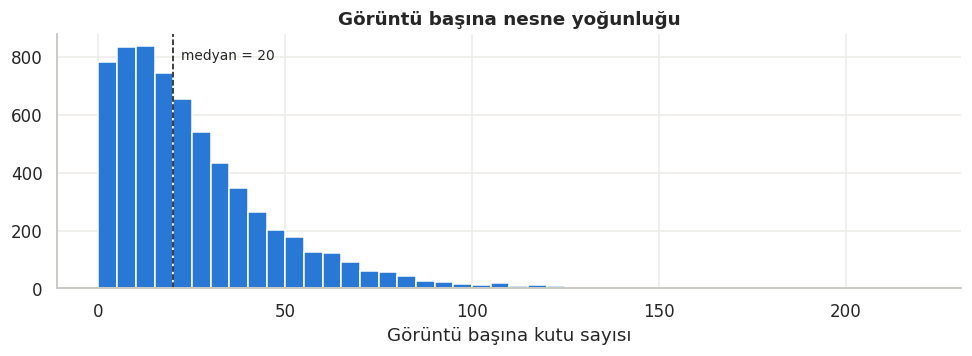

Görüntü başına kutu: medyan 20, en fazla 218


,IoU ≥ 0.5 olan gerçek kutu çifti
aynı sınıf,1248
car ↔ van,156
car ↔ truck,8
truck ↔ van,5
bus ↔ truck,3


In [7]:
per_img = ann.groupby("image_id").size().reindex(train_ids, fill_value=0)
pairs = []
for img, g in ann.groupby("image_id"):
    b, lab = g[["x", "y", "w", "h"]].to_numpy(float), g["label"].to_numpy()
    for k in range(len(b) - 1):
        o = b[k + 1:]
        iw = np.clip(np.minimum(b[k, 0] + b[k, 2], o[:, 0] + o[:, 2]) - np.maximum(b[k, 0], o[:, 0]), 0, None)
        ih = np.clip(np.minimum(b[k, 1] + b[k, 3], o[:, 1] + o[:, 3]) - np.maximum(b[k, 1], o[:, 1]), 0, None)
        iou = iw * ih / (b[k, 2] * b[k, 3] + o[:, 2] * o[:, 3] - iw * ih)
        pairs += [("aynı sınıf" if lab[k] == lab[k + 1 + j] else " ↔ ".join(sorted((lab[k], lab[k + 1 + j])))) for j in np.flatnonzero(iou >= 0.5)]
if RUN_EDA:
    fig, ax = plt.subplots(figsize=(9, 3.4))
    ax.hist(per_img, bins=np.arange(0, per_img.max() + 5, 5), color="#2a78d6", edgecolor="white")
    ax.axvline(per_img.median(), color="#0b0b0b", linestyle="--", linewidth=1)
    ax.text(per_img.median() + 2, ax.get_ylim()[1] * 0.9, f"medyan = {per_img.median():.0f}", fontsize=9)
    ax.set_xlabel("Görüntü başına kutu sayısı")
    ax.set_title("Görüntü başına nesne yoğunluğu")
    plt.tight_layout()
    plt.show()
print(f"Görüntü başına kutu: medyan {per_img.median():.0f}, en fazla {per_img.max()}")
pd.Series(pairs, dtype=str).value_counts().rename("IoU ≥ 0.5 olan gerçek kutu çifti").to_frame()

**Ne öğrendik?**
- Sahneler kalabalık: tahmin tarafında `max_det` en az 300 olmalı.
- IoU'su 0.5'in üzerinde olan binden fazla **gerçek** kutu çifti var; farklı sınıftan olanlar neredeyse tamamen car ↔ van.
  NMS **sınıf bazında** ve eşiği 0.5'in üzerinde kalmalı (Ultralytics varsayılanı: 0.7); aksi halde gerçek nesneler silinir.

### 2.6 Görsel örnekler

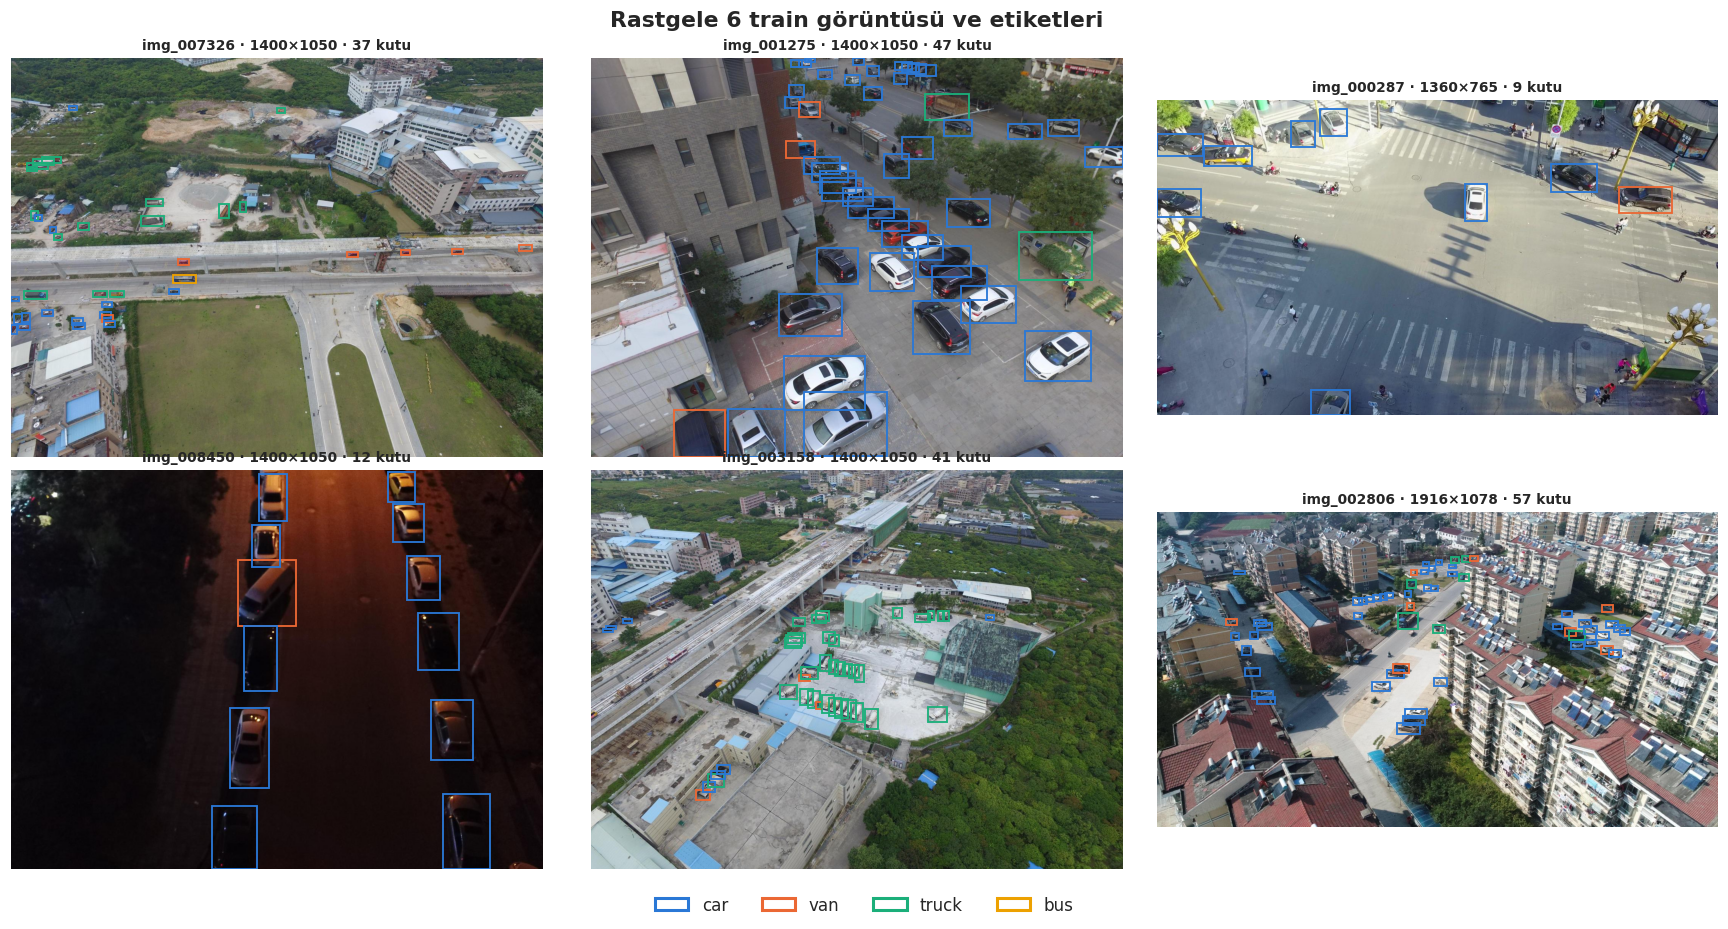

In [8]:
ann_by_img = {k: g for k, g in ann.groupby("image_id")}
legend_handles = [mpatches.Patch(facecolor="none", edgecolor=CLASS_COLORS[c], linewidth=2, label=c) for c in CLASSES]


def show_image(ax, image_id, folder=TRAIN_IMG_DIR, boxes=True):
    img = Image.open(folder / f"{image_id}.jpg")
    ax.imshow(img)
    if boxes and image_id in ann_by_img:
        for r in ann_by_img[image_id].itertuples():
            ax.add_patch(mpatches.Rectangle((r.x, r.y), r.w, r.h, fill=False, edgecolor=CLASS_COLORS[r.label], linewidth=1.2))
    ax.set_title(f"{image_id} · {img.size[0]}×{img.size[1]}" + (f" · {len(ann_by_img.get(image_id, []))} kutu" if boxes else ""), fontsize=9)
    ax.axis("off")


if RUN_EDA:
    rng = random.Random(SEED)
    fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
    for ax, i in zip(axes.flat, rng.sample(sorted(ann_by_img), 6)):
        show_image(ax, i)
    fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=False)
    fig.suptitle("Rastgele 6 train görüntüsü ve etiketleri", fontweight="bold")
    plt.tight_layout(rect=(0, 0.04, 1, 1))
    plt.show()

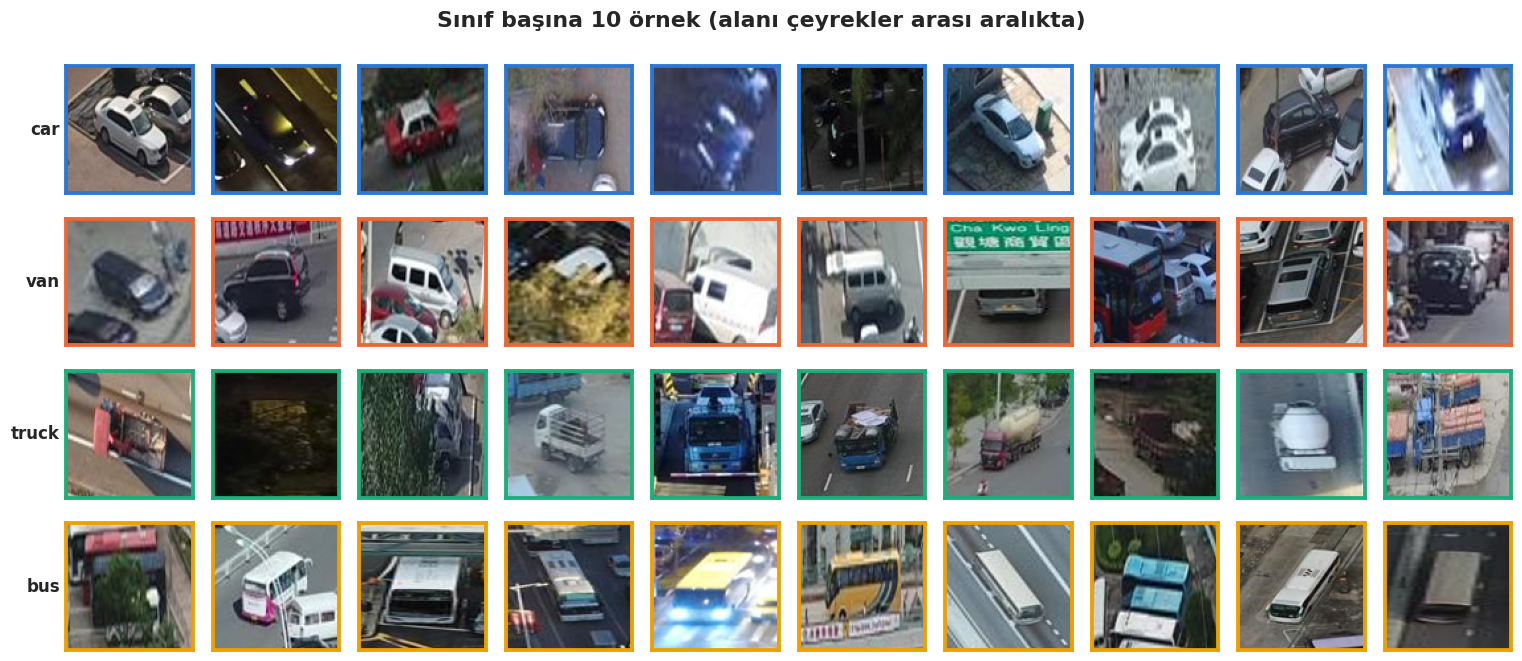

In [9]:
def crop(r, pad=0.35, thumb=96):
    img = Image.open(TRAIN_IMG_DIR / f"{r.image_id}.jpg").convert("RGB")
    px, py = r.w * pad, r.h * pad
    box = tuple(int(v) for v in (max(0, r.x - px), max(0, r.y - py), min(r.width, r.x + r.w + px), min(r.height, r.y + r.h + py)))
    return img.crop(box).resize((thumb, thumb))


if RUN_EDA:
    N = 10
    fig, axes = plt.subplots(len(CLASSES), N, figsize=(N * 1.4, len(CLASSES) * 1.55))
    for row, c in enumerate(CLASSES):
        sub = ann[ann["label"] == c]
        q25, q75 = sub["area"].quantile([.25, .75])
        for col, r in enumerate(sub[sub["area"].between(q25, q75)].sample(N, random_state=SEED).itertuples()):
            ax = axes[row, col]
            ax.imshow(crop(r))
            ax.set_xticks([])
            ax.set_yticks([])
            for s in ax.spines.values():
                s.set_visible(True)
                s.set_edgecolor(CLASS_COLORS[c])
                s.set_linewidth(2.5)
        axes[row, 0].set_ylabel(c, rotation=0, ha="right", va="center", fontsize=11, fontweight="bold")
    fig.suptitle("Sınıf başına 10 örnek (alanı çeyrekler arası aralıkta)", fontweight="bold")
    plt.tight_layout()
    plt.show()

**Ne öğrendik?** Farklı irtifa ve açılarda, gece ve gündüz çekimleri var. `car` ile `van` görsel olarak çok yakın;
en çok karışacak sınıf çifti bu olacak.

### 2.7 Yeniden boyutlandırmanın küçük nesnelere etkisi

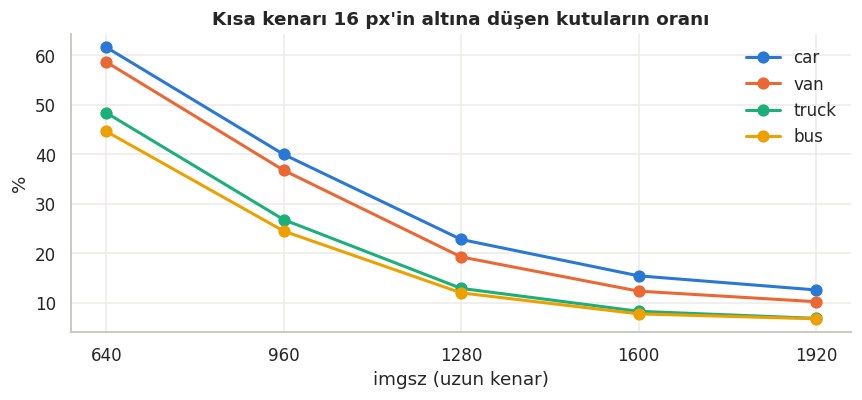

,car,van,truck,bus,tümü
imgsz,,,,,
640,61.60,58.70,48.40,44.60,59.70
960,40.00,36.80,26.80,24.50,38.10
1280,22.80,19.30,12.90,12.00,21.20
1600,15.50,12.40,8.30,7.80,14.30
1920,12.60,10.20,6.90,6.80,11.70


In [10]:
long_side = ann[["width", "height"]].max(axis=1)
min_side = ann[["w", "h"]].min(axis=1)
resize_rows = []
for s in [640, 960, 1280, 1600, 1920]:
    ms = min_side * np.minimum(1.0, s / long_side)
    resize_rows.append({"imgsz": s, **{c: (ms[ann["label"] == c] < 16).mean() * 100 for c in CLASSES}, "tümü": (ms < 16).mean() * 100})
resize_df = pd.DataFrame(resize_rows).set_index("imgsz")
if RUN_EDA:
    fig, ax = plt.subplots(figsize=(8, 3.8))
    for c in CLASSES:
        ax.plot(resize_df.index, resize_df[c], marker="o", markersize=7, linewidth=2, color=CLASS_COLORS[c], label=c)
    ax.set_xticks(resize_df.index)
    ax.set_xlabel("imgsz (uzun kenar)")
    ax.set_ylabel("%")
    ax.set_title("Kısa kenarı 16 px'in altına düşen kutuların oranı")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
resize_df.round(1)

**Ne öğrendik?** 640 piksel girişte kutuların yaklaşık %60'ının kısa kenarı 16 pikselin altına düşüyor; 1280'de bu oran ~%21.
**Çözünürlük bu veri setinde en etkili tek ayar**; eğitim `imgsz=1280` ile yapılıyor.

### 2.8 Bulgular → Modelleme kararları
| Bulgu | Karar |
|---|---|
| Nesneler çok küçük; 640'ta çoğu 16 px altına düşüyor | `imgsz=1280` |
| Sınıf dengesizliği, ama mAP'te eşit ağırlık | Sınıf bazında AP izleniyor |
| Kalabalık sahneler (görüntü başına 200'ü aşan kutu) | `max_det=300` |
| Örtüşen gerçek kutular (çoğu car ↔ van) | Sınıf bazında NMS, `iou=0.7` |
| mAP sıralama tabanlı | Değerlendirmede `conf=0.001` (eşiği yükseltmek skoru yalnızca düşürür) |
| Train ve test çözünürlük dağılımı farklı | `scene_holdout_v2` split'i + ağırlıklı mAP ve stratum bazında skor |
| Arka plan görüntüleri var | Eğitimde boş etiket dosyasıyla tutuluyor |

## 3. Veri hazırlığı: `scene_holdout_v2` split'i ve YOLO formatı
- **Split (`splits/scene_holdout_v2`):** 5,176 train / 1,295 val. Takımın ortak split'i (`furkan/src/make_scene_holdout_v2.py`, seed 42).
  - **Sahne grupları bölünmez:** Birbirine çok benzeyen görüntüler (aynı sahne) ya tamamen train'de ya tamamen val'de. Böylece val skoru,
    modelin gördüğü sahnelerin neredeyse aynısını tekrar görmesiyle şişmez.
  - **Val, testin dağılımını taklit eder:** Strata = çözünürlük × {karanlık, aydınlık}; val'in her stratumdaki payı test setindekine yakın.
    Her stratumdan val'e en fazla %50 ayrılabildiği için karanlık 1400×788 val'de testtekinden az (%8.6'ya karşı %17.9).
  - **Ağırlıklar (`val_strata.csv`):** Her val görüntüsüne stratumunun ağırlığı (p_test / p_val, ortalama 1) verilir; karanlık 1400×788 için ~2.07,
    diğerleri ~0.9. Bölüm 5'te düz mAP'nin yanında bu ağırlıklarla hesaplanan **ağırlıklı mAP** raporlanır.
  - Val listesi ve stratum ağırlıkları aşağıda gömülü (repo private olduğu için Kaggle'dan okunamıyor).
- **YOLO etiketi:** görüntü başına bir `.txt`; her satır `sınıf_id cx cy w h` (kutu **merkezi** ve boyutu, görüntü boyutuna göre **0–1**).
  CSV'de ise `x, y` **sol üst köşe** ve birim piksel. Sınıf id'leri `car=0, van=1, truck=2, bus=3`.
- Arka plan görüntüleri için boş `.txt` yazılır. Görüntüler kopyalanmaz, `/kaggle/working/yolo` altına symlink'lenir (Kaggle input salt okunur).

In [11]:
VAL_STRATA = {  # stratum: (ağırlık p_test/p_val, val görüntüleri)
    "1360x765_dark": (0.917139, """
        000889 001307 001782 002874 006720 008421
    """),
    "1360x765_light": (0.921350, """
        000015 000037 000099 000152 000157 000160 000168 000181 000192 000205 000235 000251 000287 000397 000431 000453 000459 000470 000560 000594
        000623 000624 000627 000628 000636 000639 000685 000725 000734 000747 000791 000824 000827 000863 000869 000888 000891 000911 000969 000977
        000991 000999 001083 001114 001139 001143 001192 001205 001243 001295 001316 001317 001319 001359 001376 001389 001422 001429 001456 001468
        001483 001486 001498 001519 001524 001543 001601 001635 001636 001653 001659 001854 001863 001883 001921 001943 002053 002076 002092 002179
        002200 002205 002224 002238 002345 002381 002453 002506 002513 002523 002564 002567 002584 002586 002607 002618 002680 002720 002750 002869
        002871 002880 002887 002891 002909 002914 002917 002918 002921 002938 003006 003009 003112 003133 003154 003176 003198 003208 003222 003239
        003271 003293 003309 003353 003379 003388 003410 003485 003523 003573 003582 003588 003596 003653 003660 003661 003694 003715 003726 003779
        003797 003916 003949 003985 004003 004036 004040 004043 004047 004051 004066 004074 004092 004159 004210 004288 004294 004297 004305 004309
        004332 004341 004351 004352 004364 004372 004427 004458 004494 004509 004511 004518 004522 004543 004587 004598 004630 004641 004652 004661
        004663 004720 004765 004766 004767 004781 004791 004811 004822 004823 004844 004852 004853 004859 004860 004889 004900 004902 004932 004939
        004948 004960 004983 004989 005002 005023 005039 005067 005095 005103 005112 005128 005146 005153 005167 005215 005234 005239 005252 005254
        005285 005302 005308 005328 005333 005363 005383 005445 005466 005484 005494 005529 005538 005540 005563 005566 005643 005650 005658 005676
        005715 005724 005732 005770 005776 005781 005820 005840 005910 005925 005929 005943 005946 005980 005988 006022 006036 006151 006171 006191
        006193 006206 006210 006214 006224 006225 006229 006236 006300 006312 006317 006318 006325 006343 006347 006358 006375 006420 006442 006447
        006453 006490 006500 006522 006669 006719 006736 006791 006820 006829 006845 006883 006890 006945 006965 006974 006981 007012 007025 007115
        007133 007138 007151 007165 007177 007192 007201 007207 007217 007254 007330 007348 007375 007429 007447 007450 007452 007459 007470 007476
        007499 007502 007530 007558 007570 007600 007660 007666 007678 007680 007696 007709 007739 007740 007770 007771 007819 007838 007843 007851
        007898 007900 007904 007918 007940 008035 008056 008057 008081 008100 008148 008155 008162 008254 008279 008303 008356 008398 008442 008456
        008484 008528 008574
    """),
    "1400x1050_dark": (0.978281, """
        000955 001591 002705 003097 003292 003341 003579 003838 005173 008423
    """),
    "1400x1050_light": (0.891231, """
        000062 000194 000441 000515 000543 000579 000584 000597 000620 000657 000690 000706 000771 000812 000844 000879 001056 001082 001136 001140
        001168 001197 001253 001272 001324 001330 001356 001358 001414 001424 001443 001444 001533 001600 001631 001680 001720 001743 001806 001843
        001865 001894 001897 001959 001997 002018 002060 002070 002086 002124 002212 002282 002344 002352 002361 002374 002388 002430 002478 002548
        002592 002615 002692 002737 002769 002790 002904 002940 003011 003116 003146 003185 003197 003202 003225 003299 003536 003572 003645 003707
        003849 003905 003913 003958 003987 003999 004025 004079 004101 004104 004148 004179 004192 004315 004360 004385 004391 004651 004729 004779
        004835 004869 004872 004982 004994 005047 005075 005196 005320 005323 005339 005535 005559 005577 005589 005608 005710 005738 005774 005799
        005827 005947 005982 006016 006040 006057 006472 006510 006567 006634 006661 006685 006689 006705 006827 006846 006847 006873 006976 006989
        006998 007020 007162 007197 007228 007255 007262 007321 007374 007399 007400 007409 007426 007527 007546 007562 007596 007691 007718 007772
        007809 007811 007911 007969 007996 008073 008119 008124 008200 008255 008304 008367 008382 008395 008429 008486 008513
    """),
    "1400x788_dark": (2.074481, """
        000025 000027 000158 000171 000392 000442 000505 000602 000673 000711 000880 000913 000921 000970 001081 001157 001260 001287 001341 001695
        001770 001842 001930 002007 002062 002077 002138 002190 002470 002540 002600 002619 002785 002827 002828 003083 003160 003161 003463 003475
        003489 003493 003574 003679 003892 003963 004001 004061 004164 004275 004429 004448 004489 004563 004568 004613 004671 004975 005012 005166
        005171 005250 005295 005300 005410 005430 005543 005545 005556 005607 005664 005743 005964 006044 006074 006116 006127 006279 006291 006337
        006671 006765 006767 006871 006885 007137 007176 007211 007280 007312 007440 007474 007507 007606 007716 007723 007827 007835 007913 008076
        008099 008113 008134 008164 008183 008199 008240 008275 008400 008430 008458 008469
    """),
    "1400x788_light": (0.887450, """
        000067 000074 000076 000085 000111 000145 000156 000162 000248 000269 000307 000339 000342 000350 000355 000405 000451 000489 000506 000514
        000517 000525 000553 000567 000591 000631 000640 000643 000683 000693 000703 000705 000720 000740 000741 000765 000822 000825 000887 000892
        000895 000918 000933 000935 000946 000968 000971 000997 001017 001023 001034 001050 001060 001067 001074 001098 001107 001158 001175 001202
        001212 001318 001384 001387 001413 001448 001461 001471 001504 001542 001557 001596 001602 001605 001608 001613 001621 001742 001751 001767
        001803 001809 001815 001826 001835 001851 001867 001868 001885 001889 001914 001925 001941 001966 001968 001987 002035 002043 002049 002059
        002073 002113 002117 002232 002279 002296 002297 002306 002324 002347 002364 002437 002441 002466 002481 002491 002508 002524 002551 002581
        002605 002610 002681 002691 002706 002728 002738 002747 002752 002762 002764 002792 002832 002863 002885 002910 002913 002943 003000 003094
        003115 003132 003165 003238 003241 003260 003297 003324 003342 003348 003370 003422 003427 003502 003521 003540 003544 003550 003557 003563
        003565 003589 003593 003612 003650 003659 003674 003676 003684 003699 003703 003716 003718 003728 003732 003743 003763 003768 003844 003853
        003902 003983 003994 004002 004008 004023 004038 004048 004054 004055 004071 004103 004219 004230 004233 004277 004329 004331 004335 004353
        004373 004390 004409 004453 004482 004486 004496 004557 004574 004584 004594 004601 004602 004631 004636 004657 004675 004677 004679 004752
        004793 004808 004810 004830 004855 004867 004912 005008 005028 005074 005104 005106 005141 005202 005240 005275 005311 005314 005330 005341
        005358 005399 005414 005420 005441 005455 005506 005520 005549 005572 005598 005601 005603 005609 005653 005654 005739 005752 005762 005763
        005773 005777 005782 005828 005884 005891 005892 005933 005974 005979 006004 006046 006070 006079 006093 006096 006147 006163 006166 006170
        006194 006207 006223 006243 006251 006282 006283 006297 006416 006428 006434 006449 006526 006541 006583 006616 006631 006649 006655 006668
        006678 006691 006692 006699 006757 006850 006882 006897 006904 006909 006917 006924 006931 006946 006979 006982 007024 007046 007049 007055
        007061 007071 007073 007110 007154 007187 007204 007206 007215 007222 007257 007267 007318 007341 007372 007384 007389 007391 007425 007428
        007539 007598 007614 007630 007633 007645 007683 007734 007742 007750 007753 007844 007854 007958 007961 007988 008016 008095 008143 008161
        008236 008238 008252 008284 008291 008297 008341 008388 008402 008439 008447 008448 008454 008490 008496 008508 008523 008524 008531 008547
        008569
    """),
    "1916x1078_light": (0.887743, """
        000255 000276 000414 000670 000816 000835 000852 000992 001045 001220 001390 001452 001467 001489 001649 001724 001725 001734 001737 001758
        001864 001899 001916 001946 001975 001996 002122 002175 002503 002633 002757 002788 002870 003029 003052 003080 003322 003329 003402 003647
        003706 003722 003767 003911 003920 003992 004185 004261 004286 004499 004548 004579 004617 004745 004750 004798 004807 004866 004917 004987
        005024 005139 005174 005176 005230 005296 005449 005531 005612 005651 005661 005726 005937 006168 006188 006309 006326 006494 006540 006594
        006635 006877 006949 007093 007220 007232 007244 007256 007323 007469 007593 007639 007687 007697 007710 007761 007769 007860 007955 008061
        008064 008406 008420 008510
    """),
    "1920x1080_dark": (0.611426, """
        007686
    """),
    "1920x1080_light": (0.881173, """
        000346 000596 000732 000773 001592 002000 002106 002240 002260 002423 002484 002872 003360 003426 003632 004549 004672 004708 004920 005096
        005378 005481 005887 006267 006797 007145 007159 007200 007533 007553 007681 008317 008376 008380
    """),
    "960x540_dark": (0.764282, """
        000402 002650 002937 006076
    """),
    "960x540_light": (0.884490, """
        000081 000101 000186 000304 000353 000411 000753 000772 000775 000794 000915 000974 001164 001213 001229 001331 001484 001503 001517 001551
        001644 001797 001939 001984 002030 002197 002241 002439 002461 002637 002953 002987 003062 003063 003157 003195 003301 003371 003419 003510
        003554 003604 003723 003783 003883 003978 003993 004027 004096 004121 004163 004344 004387 004463 004567 004633 004880 004918 004956 004998
        005109 005177 005271 005550 005569 005796 005981 006222 006234 006303 006362 006430 006486 006521 006528 006560 006565 006596 006622 006652
        006664 006780 006898 007000 007003 007013 007021 007118 007202 007402 007473 007475 007526 007702 007704 007805 007837 007956 007985 008030
        008065 008276 008415
    """),
}
VAL_STRATUM = {f"img_{n}": s for s, (_, ids) in VAL_STRATA.items() for n in ids.split()}
VAL_WEIGHT = pd.Series({i: VAL_STRATA[s][0] for i, s in VAL_STRATUM.items()}, name="weight")
VAL_IDS = sorted(VAL_STRATUM)
val_set = set(VAL_IDS)
split_ids = {"train": [i for i in train_ids if i not in val_set], "val": [i for i in train_ids if i in val_set]}
assert len(split_ids["val"]) == len(VAL_IDS) == 1295, "val listesi veriyle uyuşmuyor"
assert len(split_ids["train"]) == 5176, "train sayısı scene_holdout_v2 ile uyuşmuyor"
assert abs(VAL_WEIGHT.mean() - 1) < 1e-3, "stratum ağırlıklarının ortalaması 1 olmalı"
if SMOKE:  # yerel hızlı test: küçük alt küme
    rs = np.random.default_rng(SEED)
    split_ids = {k: sorted(rs.choice(v, n, replace=False)) for (k, v), n in zip(split_ids.items(), [64, 32])}

x1, y1 = ann["x"].clip(lower=0), ann["y"].clip(lower=0)
x2, y2 = (ann["x"] + ann["w"]).clip(upper=ann["width"]), (ann["y"] + ann["h"]).clip(upper=ann["height"])
yolo = pd.DataFrame({"image_id": ann["image_id"], "cls": ann["label"].map({c: k for k, c in enumerate(CLASSES)}),
                     "cx": (x1 + x2) / 2 / ann["width"], "cy": (y1 + y2) / 2 / ann["height"],
                     "w": (x2 - x1) / ann["width"], "h": (y2 - y1) / ann["height"]})
lines = {i: [f"{r.cls} {r.cx:.6f} {r.cy:.6f} {r.w:.6f} {r.h:.6f}" for r in g.itertuples()] for i, g in yolo.groupby("image_id")}

YOLO_DIR = WORK / "yolo"
shutil.rmtree(YOLO_DIR, ignore_errors=True)
for split, ids in split_ids.items():
    (YOLO_DIR / "images" / split).mkdir(parents=True)
    (YOLO_DIR / "labels" / split).mkdir(parents=True)
    for i in ids:
        dst = YOLO_DIR / "images" / split / f"{i}.jpg"
        try:
            dst.symlink_to(TRAIN_IMG_DIR / f"{i}.jpg")
        except OSError:  # Windows'ta symlink yetkisi yoksa (yalnızca yerel test)
            shutil.copy2(TRAIN_IMG_DIR / f"{i}.jpg", dst)
        rows = lines.get(i, [])
        (YOLO_DIR / "labels" / split / f"{i}.txt").write_text("\n".join(rows) + ("\n" if rows else ""))
DATA_YAML = YOLO_DIR / "dataset.yaml"
DATA_YAML.write_text(f"path: {YOLO_DIR.as_posix()}\ntrain: images/train\nval: images/val\nnc: 4\nnames:\n"
                     + "".join(f"  {k}: {c}\n" for k, c in enumerate(CLASSES)))

pd.DataFrame({s: {"görüntü": len(ids), "kutu": sum(len(lines.get(i, [])) for i in ids), "arka plan": sum(i not in lines for i in ids)}
              for s, ids in split_ids.items()}).T

,görüntü,kutu,arka plan
train,5176,134016,223
val,1295,31332,67


**Doğrulama:** Yazılan etiket dosyalarını geri okuyup piksele çeviriyoruz ve orijinal CSV ile karşılaştırıyoruz. Tek fark 6 ondalık yuvarlama olmalı.
Dönüşüm hatası (ör. sol üst köşeyi merkez sanmak) sessiz bir hatadır: eğitim çalışır ama model yanlış öğrenir.

In [12]:
back = []
for split, ids in split_ids.items():
    for i in ids:
        W, H = sizes.loc[i]
        for k, line in enumerate((YOLO_DIR / "labels" / split / f"{i}.txt").read_text().splitlines()):
            c, cx, cy, w, h = line.split()
            w, h = float(w) * W, float(h) * H
            back.append((i, k, CLASSES[int(c)], float(cx) * W - w / 2, float(cy) * H - h / 2, w, h))
back = pd.DataFrame(back, columns=["image_id", "k", "label_y", "x_y", "y_y", "w_y", "h_y"])
orig = ann[ann["image_id"].isin(set(split_ids["train"]) | set(split_ids["val"]))]
m = orig.assign(k=orig.groupby("image_id").cumcount()).merge(back, on=["image_id", "k"])
err = max((m[c] - m[f"{c}_y"]).abs().max() for c in ["x", "y", "w", "h"])
pd.Series({
    "Tüm kutular eşleşti": len(m) == len(orig) == len(back),
    "Sınıflar aynı": bool((m["label"] == m["label_y"]).all()),
    "En büyük piksel hatası < 0.01": err < 0.01,
    "Train ∩ val boş": not (set(split_ids["train"]) & set(split_ids["val"])),
    f"Split: {SPLIT_NAME} ({len(split_ids['train']):,} / {len(split_ids['val']):,})": True,
}, name="geçti mi?").to_frame()

,geçti mi?
Tüm kutular eşleşti,True
Sınıflar aynı,True
En büyük piksel hatası < 0.01,True
Train ∩ val boş,True
"Split: scene_holdout_v2 (5,176 / 1,295)",True


## 4. Eğitim
- Birden fazla GPU varsa Ultralytics **DDP** ile eğitir; notebook eğitimi ayrı bir süreçte başlatıp bitmesini bekler.
- `nbs=64` (varsayılan): gradyanlar 64 görüntüye ulaşana kadar biriktirilir, yani GPU başına batch yalnızca belleği etkiler.
- Diğer hiperparametreler ve augmentation Ultralytics varsayılanı (baseline). `best.pt`, Ultralytics'in val mAP50-95'ine göre seçilir.
- **Erken durdurma:** `patience=20`; val mAP50-95 20 epoch boyunca iyileşmezse eğitim durur ve o ana kadarki en iyi ağırlık kullanılır.

In [13]:
EXP = f"{Path(MODEL).stem}_{IMGSZ}_v2" if not SMOKE else "smoke"  # _v2: scene_holdout_v2 split
if SMOKE:
    MODEL, IMGSZ, EPOCHS = "yolo11n.pt", 320, 1
train_cfg = dict(
    data=str(DATA_YAML), imgsz=IMGSZ, epochs=EPOCHS, patience=PATIENCE, seed=SEED, cache=False, plots=True,
    batch=BATCH_PER_GPU * max(N_GPU, 1), device=(list(range(N_GPU)) if N_GPU > 1 else 0) if N_GPU else "cpu",
    workers=4 if ON_KAGGLE else 0, project=str(WORK / "runs"), name=EXP, exist_ok=True,
)
print(MODEL, train_cfg)
t0 = time.perf_counter()
YOLO(MODEL).train(**train_cfg)
TRAIN_MIN = (time.perf_counter() - t0) / 60
RUN_DIR = WORK / "runs" / EXP
BEST = RUN_DIR / "weights" / "best.pt"
print(f"Eğitim süresi: {TRAIN_MIN:.1f} dk · en iyi ağırlık: {BEST}")

yolo11m.pt {'data': '/kaggle/working/yolo/dataset.yaml', 'imgsz': 1280, 'epochs': 100, 'patience': 20, 'seed': 42, 'cache': False, 'plots': True, 'batch': 8, 'device': [0, 1], 'workers': 4, 'project': '/kaggle/working/runs', 'name': 'yolo11m_1280_v2', 'exist_ok': True}
Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      8.29G      1.184      1.051      1.027         95       1280: 100% ━━━━━━━━━━━━ 647/647 2.0it/s 5:270.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 81/81 4.2it/s 19.4s0.2s
                   all       1295      31332       0.62      0.522      0.558      0.378

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100      8.19G      1.171       1.04      1.029        139       1280: 100% ━━━━━━━━━━━━ 647/647 2.0it/s 5:270.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 81/81 4.2it/s 19.3s0.2s
                   all       1295      31332      0.639      0.556      0.584        0.4

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/100      8.38G       1.16     0.9911      1.022        317       12

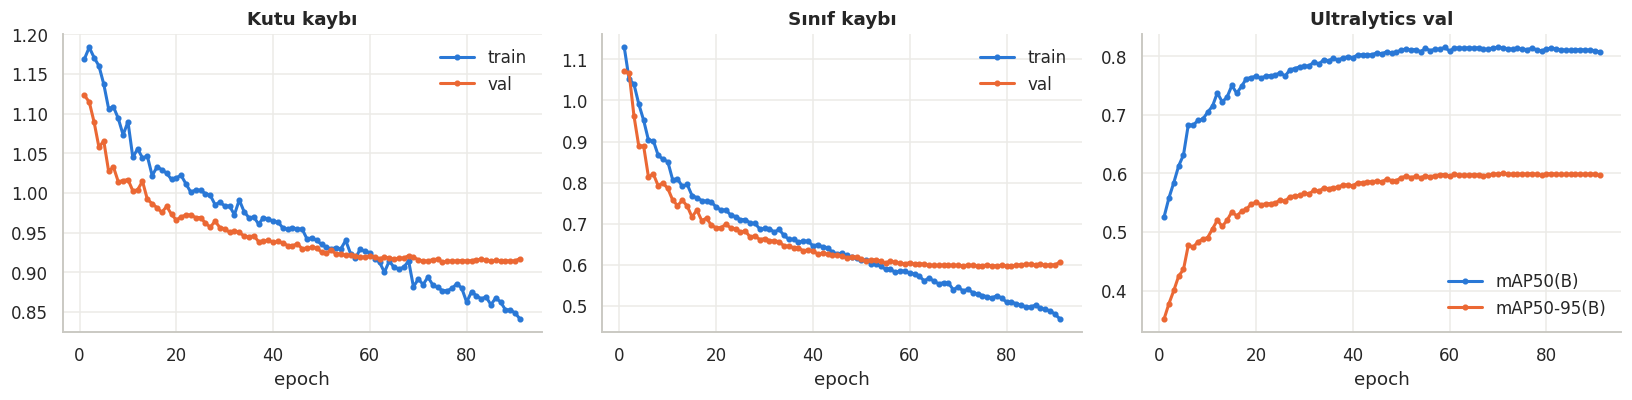

In [14]:
hist = pd.read_csv(RUN_DIR / "results.csv")
hist.columns = hist.columns.str.strip()
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, (title, cols) in zip(axes, [("Kutu kaybı", ["train/box_loss", "val/box_loss"]), ("Sınıf kaybı", ["train/cls_loss", "val/cls_loss"]),
                                    ("Ultralytics val", ["metrics/mAP50(B)", "metrics/mAP50-95(B)"])]):
    for col, color in zip(cols, ["#2a78d6", "#eb6834"]):
        ax.plot(hist["epoch"], hist[col], marker="o", markersize=3, linewidth=2, color=color,
                label=col.split("/")[-1] if "metrics" in col else col.split("/")[0])
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 5. Yarışma metriğiyle değerlendirme (mAP@0.5)
Kurallar (takımın `metrics.py` değerlendiricisiyle aynı; pycocotools ile çapraz doğrulandı):
- Tahminler sınıf bazında güvene göre sıralanır. Her tahmin, aynı görüntüde aynı sınıftan **henüz eşleşmemiş** ve IoU'su en yüksek gerçek kutuyla eşleşir.
  IoU ≥ 0.5 ise TP, değilse FP.
- 200 px²'den küçük tahminler puanı etkilemez, değerlendirmeden önce atılır.
- AP = precision-recall zarfının altındaki alan (all-point); skor = 4 sınıfın AP ortalaması.
- **Ağırlıklı mAP:** Her görüntünün TP, FP ve gerçek kutu sayıları o görüntünün stratum ağırlığıyla çarpılır (`furkan/src/weighted_map.py` ile aynı yöntem). Val'i test dağılımına göre yeniden ağırlıklandırdığı için **birincil karşılaştırma ölçütü budur**.

In [15]:
def iou_one_to_many(box, boxes):
    x1 = np.maximum(box[0], boxes[:, 0]); y1 = np.maximum(box[1], boxes[:, 1])
    x2 = np.minimum(box[0] + box[2], boxes[:, 0] + boxes[:, 2]); y2 = np.minimum(box[1] + box[3], boxes[:, 1] + boxes[:, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    return inter / np.maximum(box[2] * box[3] + boxes[:, 2] * boxes[:, 3] - inter, 1e-9)


def evaluate(gt, pred, iou_thr=0.5, min_area=MIN_AREA, weights=None):
    # weights: image_id -> ağırlık (None ise hepsi 1). TP, FP ve gerçek kutular görüntü ağırlığıyla sayılır.
    pred = pred[pred["w"] * pred["h"] >= min_area]
    wmap = (lambda ids: np.ones(len(ids))) if weights is None else (lambda ids: pd.Series(weights).reindex(ids).fillna(1.0).to_numpy())
    rows, curves = [], {}
    for c in CLASSES:
        g = gt[gt["label"] == c]
        p = pred[pred["label"] == c].sort_values("conf", ascending=False, kind="mergesort")
        gt_boxes = {i: gg[["x", "y", "w", "h"]].to_numpy(float) for i, gg in g.groupby("image_id")}
        matched = {i: np.zeros(len(b), bool) for i, b in gt_boxes.items()}
        tp = np.zeros(len(p), bool)
        pw, npos = wmap(p["image_id"].to_numpy()), float(wmap(g["image_id"].to_numpy()).sum())
        for k, (img, box) in enumerate(zip(p["image_id"].to_numpy(), p[["x", "y", "w", "h"]].to_numpy(float))):
            boxes = gt_boxes.get(img)
            if boxes is None:
                continue
            ious = iou_one_to_many(box, boxes)
            ious[matched[img]] = -1
            j = int(ious.argmax())
            if ious[j] >= iou_thr:
                tp[k] = matched[img][j] = True
        ctp, cfp = np.cumsum(tp * pw), np.cumsum(~tp * pw)
        recall = ctp / max(npos, 1e-12)
        precision = ctp / np.maximum(ctp + cfp, 1e-12)
        env = np.maximum.accumulate(precision[::-1])[::-1] if len(tp) else np.array([])
        ap = float(np.sum(np.diff(np.concatenate([[0], recall])) * env)) if len(g) else np.nan
        curves[c] = (recall, precision)
        rows.append({"class": c, "AP": ap, "n_gt": len(g), "TP": int(tp.sum()), "FP": int((~tp).sum()),
                     "max_recall": float(recall[-1]) if len(recall) else 0.0})
    per_class = pd.DataFrame(rows).set_index("class")
    return float(np.nanmean(per_class["AP"])), per_class, curves


best = YOLO(str(BEST))
dev = 0 if N_GPU else "cpu"
val_paths = [str(YOLO_DIR / "images" / "val" / f"{i}.jpg") for i in split_ids["val"]]
frames, t0 = [], time.perf_counter()
for s in range(0, len(val_paths), 16):
    for r in best.predict(val_paths[s:s + 16], imgsz=IMGSZ, conf=0.001, iou=0.7, max_det=300, device=dev,
                          quantize=16 if N_GPU else None, stream=True, verbose=False):
        if r.boxes is None or len(r.boxes) == 0:
            continue
        h_img, w_img = r.orig_shape
        xyxy = r.boxes.xyxy.cpu().numpy().astype(float)
        xyxy[:, [0, 2]] = xyxy[:, [0, 2]].clip(0, w_img)
        xyxy[:, [1, 3]] = xyxy[:, [1, 3]].clip(0, h_img)
        frames.append(pd.DataFrame({"image_id": Path(r.path).stem, "label": [r.names[int(c)] for c in r.boxes.cls.cpu().numpy()],
                                    "conf": r.boxes.conf.cpu().numpy(), "x": xyxy[:, 0], "y": xyxy[:, 1],
                                    "w": xyxy[:, 2] - xyxy[:, 0], "h": xyxy[:, 3] - xyxy[:, 1]}))
preds = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=["image_id", "label", "conf", "x", "y", "w", "h"])
PRED_SEC = time.perf_counter() - t0

gt_val = ann[ann["image_id"].isin(set(split_ids["val"]))]
MAP50, per_class, curves = evaluate(gt_val, preds)
MAP50_W, per_class_w, _ = evaluate(gt_val, preds, weights=VAL_WEIGHT if not SMOKE else None)
per_class.insert(1, "AP (ağırlıklı)", per_class_w["AP"])
uv = best.val(data=str(DATA_YAML), imgsz=IMGSZ, batch=16 if N_GPU else 4, conf=0.001, iou=0.7, max_det=300,
              device=dev, plots=False, verbose=False)
per_class["Ultralytics AP50"] = pd.Series(uv.box.ap50, index=[uv.names[i] for i in uv.box.ap_class_index])
print(f"{len(val_paths):,} val görüntüsü · {len(preds):,} tahmin · {PRED_SEC:.0f} sn")
print(f"mAP@0.5 ağırlıklı (test dağılımına göre, birincil): {MAP50_W:.4f}")
print(f"mAP@0.5 düz: {MAP50:.4f} · Ultralytics mAP50: {uv.box.map50:.4f}")
per_class

Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11m summary (fused): 125 layers, 20,033,116 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 323.5±206.4 MB/s, size: 193.5 KB)
val: Scanning /kaggle/working/yolo/labels/val.cache... 1295 images, 67 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1295/1295 388.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 81/81 1.3s/it 1:431.6sss
                   all       1295      31332      0.805      0.757      0.814      0.603
Speed: 1.8ms preprocess, 74.3ms inference, 0.0ms loss, 1.0ms postprocess per image
1,295 val görüntüsü · 137,147 tahmin · 89 sn
mAP@0.5 ağırlıklı (test dağılımına göre, birincil): 0.7739
mAP@0.5 düz: 0.7813 · Ultralytics mAP50: 0.8144


,AP,AP (ağırlıklı),n_gt,TP,FP,max_recall,Ultralytics AP50
class,,,,,,,
car,0.90,0.90,22514,21622,66027,0.96,0.91
van,0.65,0.64,4607,3467,8775,0.75,0.73
truck,0.74,0.74,2629,2283,14921,0.87,0.76
bus,0.83,0.82,1582,1420,5324,0.90,0.85


Ultralytics'in skoru yakın ama birebir aynı olmak zorunda değil: farklı interpolasyon kullanıyor ve 200 px² altı tahminleri atmıyor.
**Karşılaştırmalarda referans, yarışma metriğinin ağırlıklı hâli** (`AP (ağırlıklı)`); düz AP ikincil.

In [16]:
# Stratum bazında: çözünürlük × {karanlık, aydınlık}. "test payı" = stratumun testteki beklenen payı (ağırlık × val payı)
val_stratum = pd.Series({i: VAL_STRATUM[i] for i in split_ids["val"]})
by_group = pd.DataFrame({s: {"görüntü": len(ids), "ağırlık": VAL_STRATA[s][0], "val payı (%)": len(ids) / len(val_stratum) * 100,
                             "test payı (%)": VAL_STRATA[s][0] * len(ids) / len(val_stratum) * 100,
                             "mAP@0.5": evaluate(gt_val[gt_val["image_id"].isin(ids)], preds[preds["image_id"].isin(ids)])[0]}
                         for s, ids in val_stratum.groupby(val_stratum).groups.items()}).T.sort_values("test payı (%)", ascending=False)
print(f"Ağırlıklı mAP@0.5: {MAP50_W:.4f} · düz mAP@0.5: {MAP50:.4f}")
print("Not: az görüntülü strata (ör. < 20) gürültülüdür; yorumlarken 'görüntü' sütununa bakın.")
by_group

Ağırlıklı mAP@0.5: 0.7739 · düz mAP@0.5: 0.7813
Not: az görüntülü strata (ör. < 20) gürültülüdür; yorumlarken 'görüntü' sütununa bakın.


,görüntü,ağırlık,val payı (%),test payı (%),mAP@0.5
1400x788_light,381.00,0.89,29.42,26.11,0.81
1360x765_light,363.00,0.92,28.03,25.83,0.75
1400x788_dark,112.00,2.07,8.65,17.94,0.66
1400x1050_light,177.00,0.89,13.67,12.18,0.76
1916x1078_light,104.00,0.89,8.03,7.13,0.75
960x540_light,103.00,0.88,7.95,7.03,0.70
1920x1080_light,34.00,0.88,2.63,2.31,0.77
1400x1050_dark,10.00,0.98,0.77,0.76,0.78
1360x765_dark,6.00,0.92,0.46,0.42,0.71
960x540_dark,4.00,0.76,0.31,0.24,0.96


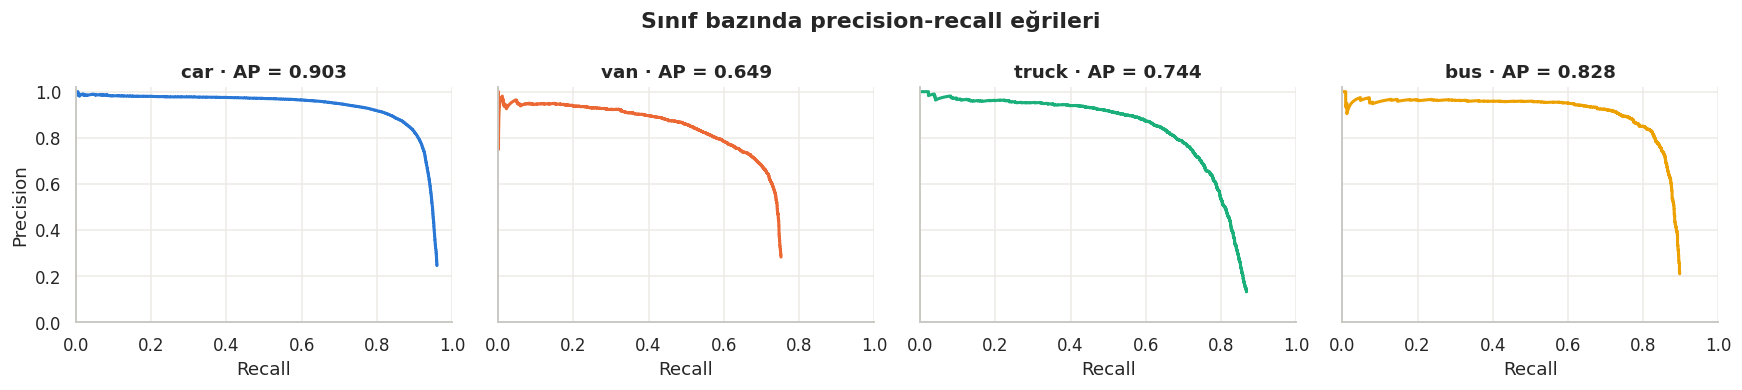

label,car,van,truck,bus
gerçek kutu alanı (px²),,,,
200–512,0.80,0.57,0.47,0.67
512–1024 (≤32²),0.91,0.69,0.63,0.74
1024–4096,0.94,0.78,0.78,0.86
4096–9216 (≤96²),0.97,0.82,0.87,0.92
> 9216,0.97,0.80,0.87,0.92


In [17]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for ax, c in zip(axes, CLASSES):
    rec, prec = curves[c]
    ax.plot(rec, prec, linewidth=2, color=CLASS_COLORS[c])
    ax.set_title(f"{c} · AP = {per_class.loc[c, 'AP']:.3f}")
    ax.set_xlabel("Recall")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
axes[0].set_ylabel("Precision")
fig.suptitle("Sınıf bazında precision-recall eğrileri", fontweight="bold")
plt.tight_layout()
plt.show()

# Nesne boyutuna göre recall (conf ≥ 0.25 tahminlerle IoU ≥ 0.5 eşleşme)
conf_by = {k: g[["x", "y", "w", "h"]].to_numpy(float) for k, g in preds[preds["conf"] >= 0.25].groupby(["image_id", "label"])}
hit = [bool((b := conf_by.get((r.image_id, r.label))) is not None and (iou_one_to_many(np.array([r.x, r.y, r.w, r.h], float), b) >= 0.5).any())
       for r in gt_val.itertuples()]
(gt_val.assign(hit=hit).pivot_table(index="size_bin", columns="label", values="hit", aggfunc="mean", observed=False)[CLASSES]
 .round(3).rename_axis("gerçek kutu alanı (px²)"))

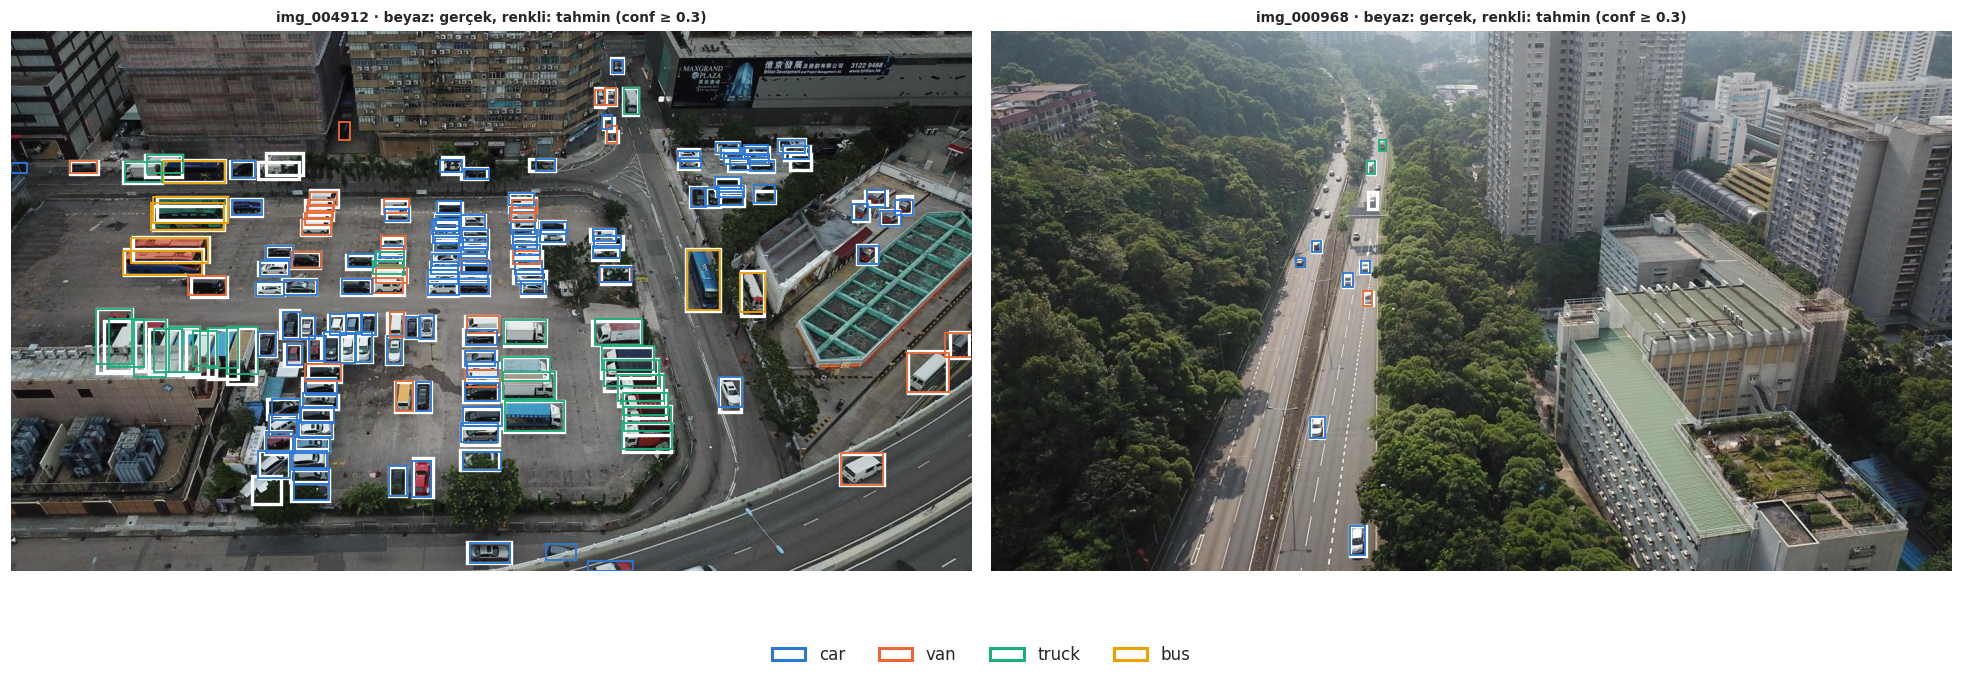

In [18]:
def show_pred_vs_gt(ax, image_id, min_conf=0.3):
    ax.imshow(Image.open(TRAIN_IMG_DIR / f"{image_id}.jpg"))
    for r in gt_val[gt_val["image_id"] == image_id].itertuples():
        ax.add_patch(mpatches.Rectangle((r.x, r.y), r.w, r.h, fill=False, edgecolor="white", linewidth=2.2))
    for r in preds[(preds["image_id"] == image_id) & (preds["conf"] >= min_conf)].itertuples():
        ax.add_patch(mpatches.Rectangle((r.x, r.y), r.w, r.h, fill=False, edgecolor=CLASS_COLORS[r.label], linewidth=1.2))
    ax.set_title(f"{image_id} · beyaz: gerçek, renkli: tahmin (conf ≥ {min_conf})", fontsize=9)
    ax.axis("off")


counts = gt_val.groupby("image_id").size()
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))
for ax, i in zip(axes, [counts.idxmax(), counts.sample(1, random_state=1).index[0]]):
    show_pred_vs_gt(ax, i)
fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

## 6. Çıktılar

In [19]:
OUT = WORK / "outputs" / EXP
OUT.mkdir(parents=True, exist_ok=True)
shutil.copy2(BEST, OUT / "best.pt")
preds.to_csv(OUT / "val_preds.csv", index=False)
for name in ["results.csv", "results.png", "confusion_matrix_normalized.png", "args.yaml"]:
    if (RUN_DIR / name).exists():
        shutil.copy2(RUN_DIR / name, OUT / name)
summary = {
    "experiment": EXP, "split": SPLIT_NAME, "model": MODEL, "imgsz": IMGSZ, "epochs": EPOCHS, "patience": PATIENCE, "epochs_run": int(len(hist)), "batch": train_cfg["batch"], "smoke": SMOKE,
    "gpus": [torch.cuda.get_device_name(i) for i in range(N_GPU)],
    "versions": {"ultralytics": ultralytics.__version__, "torch": torch.__version__},
    "train_minutes": round(TRAIN_MIN, 1),
    "mAP50_weighted": MAP50_W, "mAP50": MAP50, "ultralytics_mAP50": float(uv.box.map50),
    "per_class_AP_weighted": per_class["AP (ağırlıklı)"].to_dict(),
    "per_class_AP": per_class["AP"].to_dict(), "max_recall": per_class["max_recall"].to_dict(),
    "by_stratum_mAP50": by_group["mAP@0.5"].to_dict(),
}
(OUT / "summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(summary, indent=2, ensure_ascii=False))
print("\nÇıktılar:", OUT, sorted(p.name for p in OUT.iterdir()))

{
  "experiment": "yolo11m_1280_v2",
  "split": "scene_holdout_v2",
  "model": "yolo11m.pt",
  "imgsz": 1280,
  "epochs": 100,
  "patience": 20,
  "epochs_run": 91,
  "batch": 8,
  "smoke": false,
  "gpus": [
    "Tesla T4",
    "Tesla T4"
  ],
  "versions": {
    "ultralytics": "8.4.163",
    "torch": "2.10.0+cu128"
  },
  "train_minutes": 531.7,
  "mAP50_weighted": 0.7738694988530719,
  "mAP50": 0.7812727384360316,
  "ultralytics_mAP50": 0.814380523072916,
  "per_class_AP_weighted": {
    "car": 0.9022563802639814,
    "van": 0.6404689471795082,
    "truck": 0.7369968111908961,
    "bus": 0.8157558567779015
  },
  "per_class_AP": {
    "car": 0.9030885990120007,
    "van": 0.6492391121966695,
    "truck": 0.7444180750556517,
    "bus": 0.8283451674798046
  },
  "max_recall": {
    "car": 0.9603802078706583,
    "van": 0.7525504666811375,
    "truck": 0.8683910232027386,
    "bus": 0.8975979772439949
  },
  "by_stratum_mAP50": {
    "1400x788_light": 0.81027047400126,
    "1360x765_li

In [20]:
from pathlib import Path
import shutil
from IPython.display import FileLink, display

folder = WORK / "runs" / EXP
if not folder.is_dir():
    raise FileNotFoundError(f"Klasör bulunamadı: {folder}")

zip_path = shutil.make_archive(
    str(WORK / EXP),
    "zip",
    root_dir=folder.parent,
    base_dir=folder.name,
)

print(f"ZIP hazır: {Path(zip_path).stat().st_size / 1024**2:.1f} MB")
display(FileLink(zip_path, result_html_prefix="İndir: "))

ZIP hazır: 77.3 MB


/kaggle/working/yolo11m_1280_v2.zip

In [21]:
from pathlib import Path
import json
import pandas as pd
import torch
from ultralytics import YOLO

WEIGHTS = WORK / "runs" / EXP / "weights" / "best.pt"
assert WEIGHTS.is_file(), f"Model bulunamadı: {WEIGHTS}"
assert Path(DATA_YAML).is_file(), "Önce veri hazırlama hücrelerini çalıştır."

model = YOLO(str(WEIGHTS))
assert model.names == {0: "car", 1: "van", 2: "truck", 3: "bus"}

DEVICE = 0 if torch.cuda.is_available() else "cpu"

val_metrics = model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=1280,
    batch=4,
    device=DEVICE,
    conf=0.001,
    iou=0.7,                 # NMS eşiği; AP50'nin eşleştirme eşiği değil
    max_det=300,
    agnostic_nms=False,
    plots=True,
    project=str(WORK / "evaluation"),
    name=f"{EXP}_val",
)

val_scores = {
    "val_mAP50": float(val_metrics.box.map50),
    "val_mAP50_95": float(val_metrics.box.map),
    "val_precision": float(val_metrics.box.mp),
    "val_recall": float(val_metrics.box.mr),
}

class_scores = pd.DataFrame({
    "class": [
        model.names[int(i)]
        for i in val_metrics.box.ap_class_index
    ],
    "AP50": val_metrics.box.ap50,
    "AP50_95": val_metrics.box.ap,
})

print(json.dumps(val_scores, indent=2))
display(class_scores)

Path("/kaggle/working/val_scores.json").write_text(
    json.dumps(val_scores, indent=2), encoding="utf-8"
)
class_scores.to_csv("/kaggle/working/val_class_scores.csv", index=False)

Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11m summary (fused): 125 layers, 20,033,116 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 221.5±125.4 MB/s, size: 172.0 KB)
val: Scanning /kaggle/working/yolo/labels/val.cache... 1295 images, 67 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1295/1295 258.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 324/324 3.1it/s 1:430.4sss
                   all       1295      31332      0.805      0.757      0.814      0.603
                   car       1211      22514       0.86      0.866      0.914      0.675
                   van        958       4607       0.72      0.664      0.731       0.55
                 truck        720       2629      0.786      0.697      0.763      0.551
                   bus        482       1582      0.853      0.799       0.85      0.637
Speed: 2.1ms preprocess, 72.

,class,AP50,AP50_95
0,car,0.91,0.68
1,van,0.73,0.55
2,truck,0.76,0.55
3,bus,0.85,0.64


In [22]:
import numpy as np
from tqdm.auto import tqdm

sample_path = Path(DATA) / "sample_submission.csv"
test_dir = Path(DATA) / "test/images"

sample = pd.read_csv(sample_path, dtype={"image_id": str})
assert list(sample.columns) == ["image_id", "PredictionString"]
assert sample["image_id"].is_unique
assert len(sample) == 2118, f"Beklenmeyen test sayısı: {len(sample)}"

image_ids = sample["image_id"].tolist()
test_paths = [test_dir / f"{image_id}.jpg" for image_id in image_ids]

missing = [str(p) for p in test_paths if not p.is_file()]
assert not missing, f"Eksik test görüntüleri: {missing[:5]}"

prediction_strings = {}

for start in tqdm(range(0, len(test_paths), 4), desc="Test tahminleri"):
    chunk = test_paths[start:start + 4]

    results = model.predict(
        source=[str(p) for p in chunk],
        imgsz=1280,
        batch=4,
        device=DEVICE,
        conf=0.001,
        iou=0.7,
        max_det=300,
        agnostic_nms=False,
        stream=True,
        verbose=False,
    )

    for result in results:
        image_id = Path(result.path).stem
        height, width = result.orig_shape
        parts = []

        if result.boxes is not None:
            for box in result.boxes.data.cpu().numpy():
                x1, y1, x2, y2, confidence, class_id = box
                assert np.isfinite(box).all(), f"Geçersiz tahmin: {image_id}"

                # Orijinal görüntü sınırına kırp.
                x1, x2 = np.clip([x1, x2], 0, width)
                y1, y2 = np.clip([y1, y2], 0, height)

                x1, y1, x2, y2 = map(
                    int, np.rint([x1, y1, x2, y2])
                )
                w, h = x2 - x1, y2 - y1

                if w <= 0 or h <= 0:
                    continue

                label = model.names[int(class_id)]
                parts.append(
                    f"{label} {confidence:.6f} {x1} {y1} {w} {h}"
                )

        assert image_id not in prediction_strings
        prediction_strings[image_id] = " ".join(parts) if parts else "none"

assert set(prediction_strings) == set(image_ids)

submission = sample.copy()
submission["PredictionString"] = submission["image_id"].map(
    prediction_strings
)

assert submission["image_id"].equals(sample["image_id"])
assert submission["PredictionString"].notna().all()
assert submission["PredictionString"].str.len().gt(0).all()

output = Path("/kaggle/working/submission.csv")
submission.to_csv(output, index=False)

print(f"Hazır: {output}")
print(f"Satır sayısı: {len(submission)}")
print(f"Tahminsiz görüntü: {(submission.PredictionString == 'none').sum()}")
display(submission.head())

Test tahminleri:   0%|          | 0/530 [00:00<?, ?it/s]

Hazır: /kaggle/working/submission.csv
Satır sayısı: 2118
Tahminsiz görüntü: 2


,image_id,PredictionString
0,img_000001,car 0.909450 1158 604 160 131 car 0.904329 976...
1,img_000002,car 0.890741 404 553 503 210 truck 0.874399 39...
2,img_000003,car 0.899294 633 563 109 56 car 0.889359 928 6...
3,img_000004,car 0.868969 1327 615 102 54 truck 0.868345 1 ...
4,img_000008,bus 0.905674 488 560 194 132 bus 0.904408 1020...
